In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("advertisingData.csv")

In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


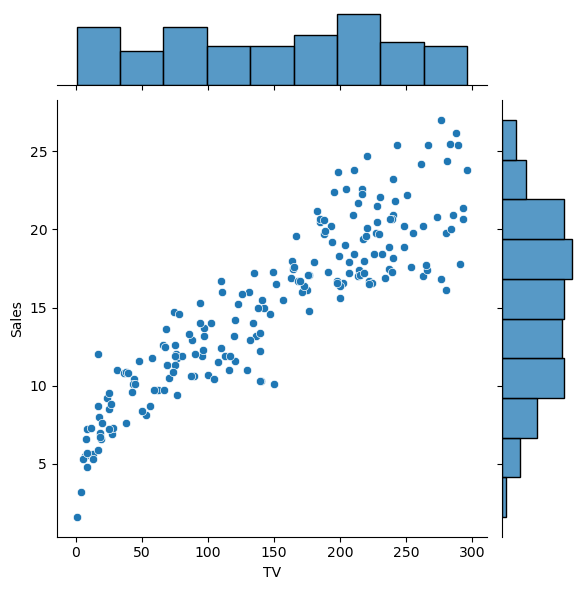

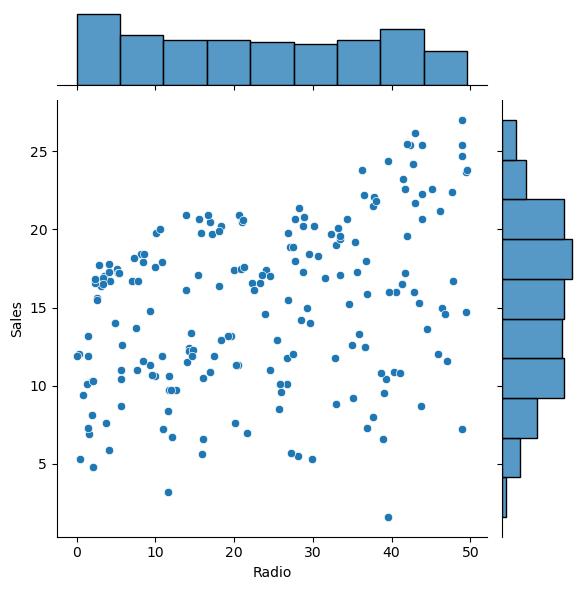

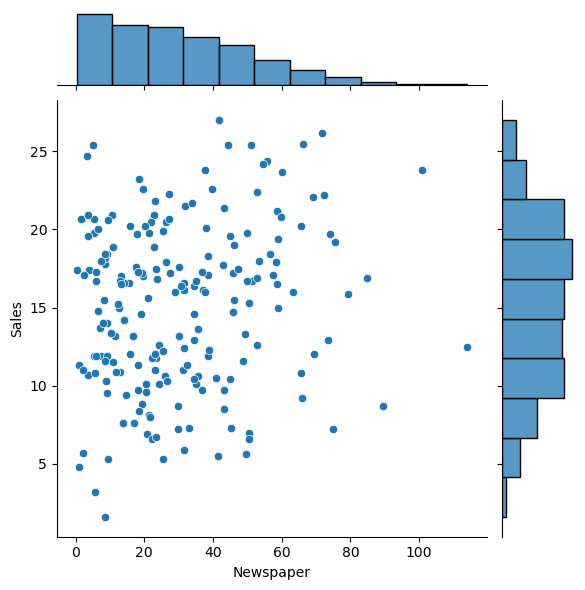

In [11]:
# EDA

sns.jointplot(x="TV", y="Sales", data=df)
sns.jointplot(x="Radio", y="Sales", data=df)
sns.jointplot(x="Newspaper", y="Sales", data=df)

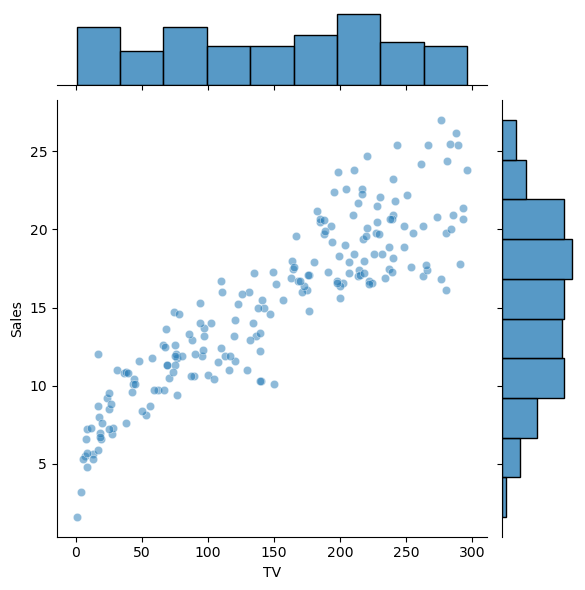

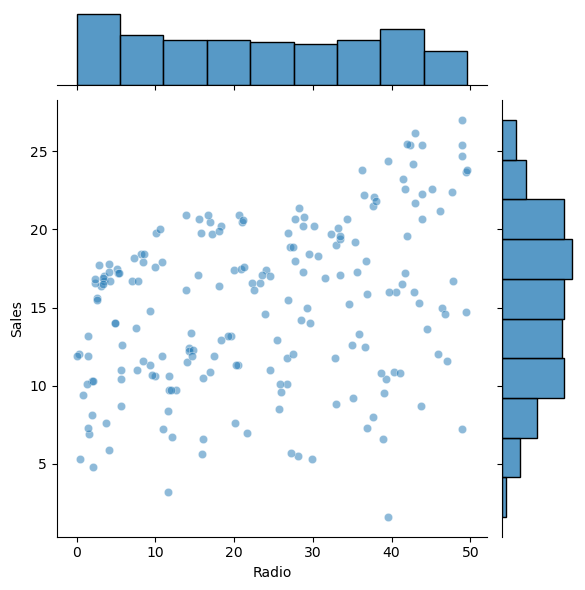

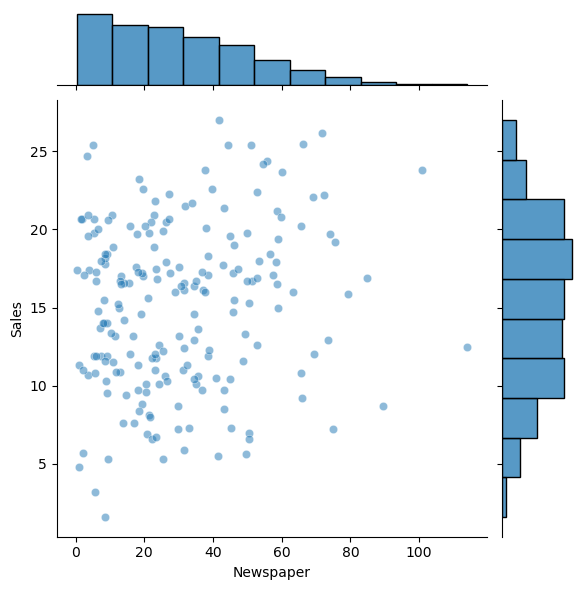

In [16]:
sns.jointplot(x="TV", y="Sales", data=df, alpha=0.5)
sns.jointplot(x="Radio", y="Sales", data=df, alpha=0.5)
sns.jointplot(x="Newspaper", y="Sales", data=df, alpha=0.5)

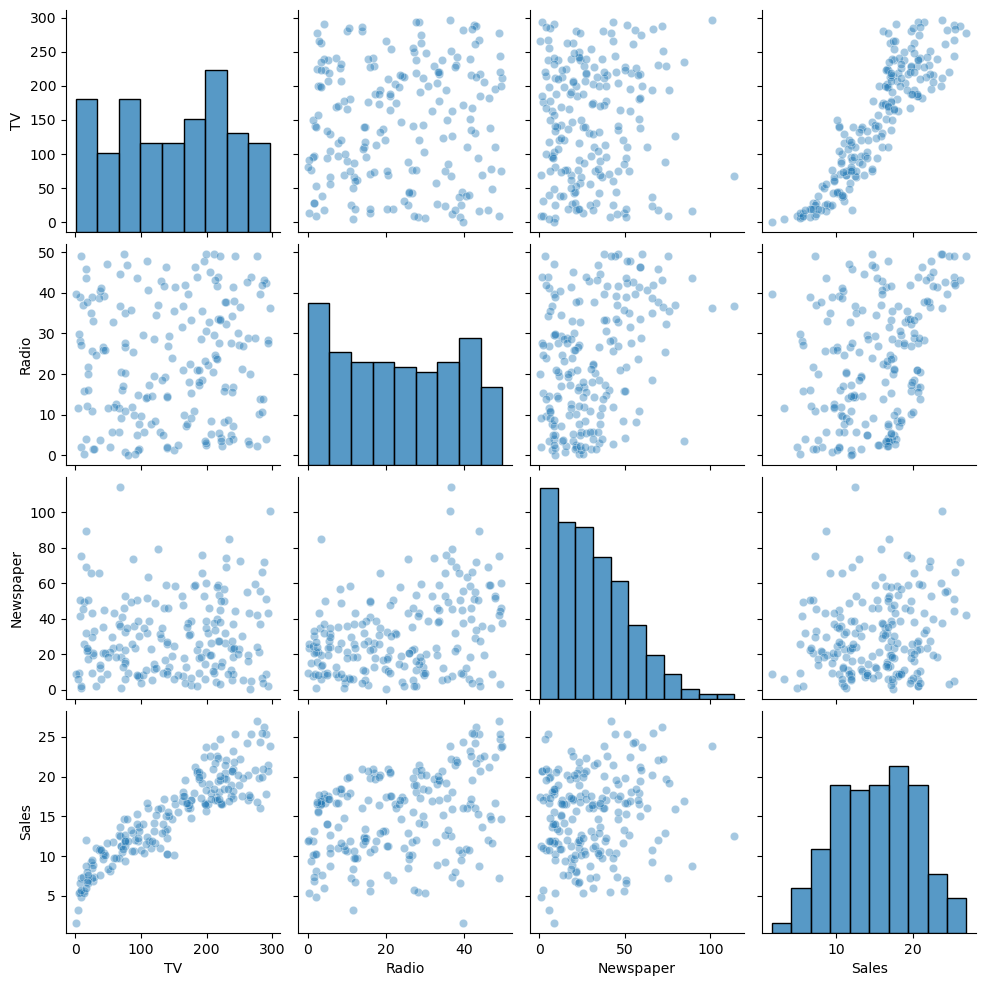

In [18]:
sns.pairplot(df, kind='scatter', plot_kws={'alpha':0.4})

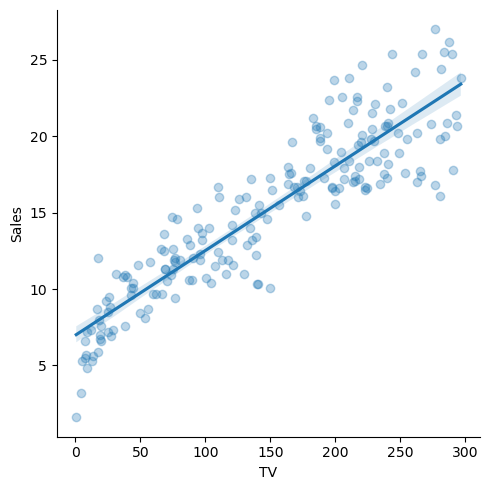

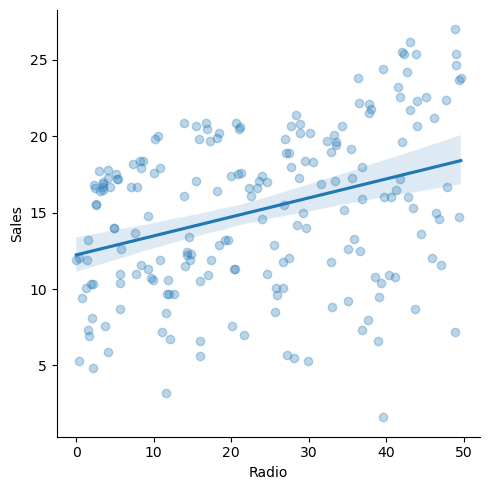

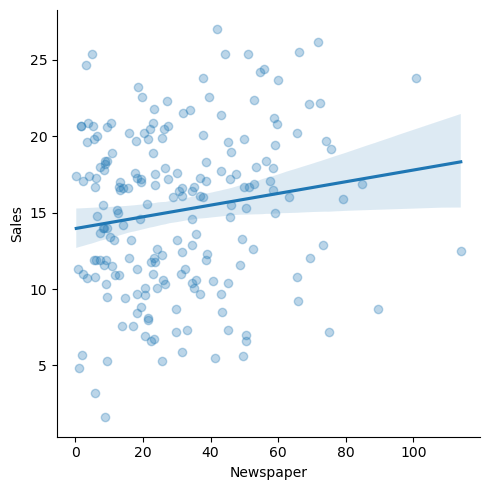

In [23]:
sns.lmplot(x="TV", y="Sales", data=df, scatter_kws={'alpha':0.3})
sns.lmplot(x="Radio", y="Sales", data=df, scatter_kws={'alpha':0.3})
sns.lmplot(x="Newspaper", y="Sales", data=df, scatter_kws={'alpha':0.3})

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
X_train

,TV,Radio,Newspaper
169,284.3,10.6,6.4
97,184.9,21.0,22.0
31,112.9,17.4,38.6
12,23.8,35.1,65.9
35,290.7,4.1,8.5
...,...,...,...
106,25.0,11.0,29.7
14,204.1,32.9,46.0
92,217.7,33.5,59.0
179,165.6,10.0,17.6


In [44]:
# Training the model

In [45]:
from sklearn.linear_model import LinearRegression

In [47]:
lm = LinearRegression()

In [50]:
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
lm.coef_

array([0.05358869, 0.10270677, 0.00793167])

In [58]:
cdf = pd.DataFrame(lm.coef_, index=X.columns, columns=["Coef"])
print(cdf)

               Coef
TV         0.053589
Radio      0.102707
Newspaper  0.007932


In [59]:
# predictions

In [61]:
predictions = lm.predict(X_test)

In [62]:
predictions

array([17.15991908, 20.53369503, 23.68914396,  9.5191455 , 21.60736836,
       12.78101318, 21.08636345,  8.76054246, 17.11499951, 16.68789636,
        8.97584663,  8.57645026, 18.33212325,  8.17863567, 12.64605571,
       14.94486946,  8.34939536, 17.83858948, 11.12172174, 20.37740648,
       20.9483297 , 13.04035779, 11.01360656, 22.51142595,  9.40369784,
        7.98591291, 20.86943368, 13.77882255, 10.83407064,  8.00419229,
       15.88597618, 10.7027424 , 20.9521718 , 10.84679243, 21.50720813,
       21.07347295, 12.22673775, 22.85273767, 12.57698182,  6.54597206,
       11.93411853, 15.23490068, 10.07411153,  9.52159696, 17.11786382,
        7.28032677, 10.49404864, 15.24356754, 11.20742176, 11.78392665,
       14.01472163, 14.59884572, 10.82722434,  9.55839415,  9.03749681,
       12.51183313, 10.52551021, 25.01900824,  7.99334943, 15.73916263])

Text(0.5, 1.0, 'Evaluation of our LM model')

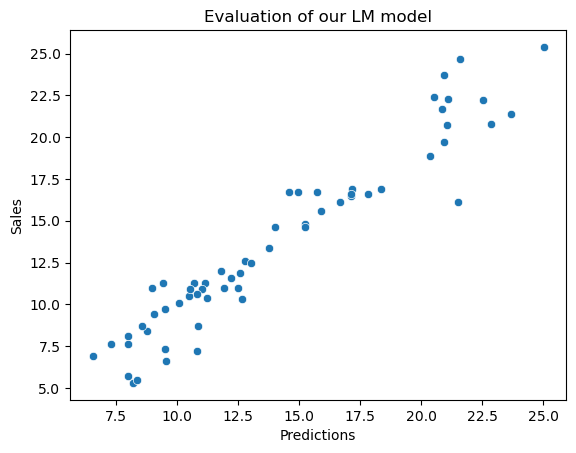

In [65]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions")
plt.title("Evaluation of our LM model")

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [67]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  1.1594875061090584
Mean Squared Error:  2.541624036229149
RMSE:  1.5942471691143594


In [71]:
#residuals
residuals = y_test - predictions
residuals

95    -0.259919
15     1.866305
30    -2.289144
158   -2.219146
128    3.092632
115   -0.181013
69     1.213637
170   -0.360542
174   -0.615000
45    -0.587896
66     2.024153
182    0.123550
165   -1.432123
78    -2.878636
186   -2.346056
177    1.755131
56    -2.849395
152   -1.238589
82     0.178278
68    -1.477406
124   -1.248330
16    -0.540358
148   -0.113607
93    -0.311426
65     1.896302
60     0.114087
84     0.830566
67    -0.378823
125   -0.234071
132   -2.304192
9     -0.285976
18     0.597258
55     2.747828
75    -2.146792
150   -5.407208
104   -0.373473
135   -0.626738
137   -2.052738
164   -0.676982
76     0.354028
79    -0.934119
197   -0.434901
38     0.025888
24     0.178403
122   -0.517864
195    0.319673
29     0.005951
19    -0.643568
143   -0.807422
86     0.216073
114    0.585278
173    2.101154
5     -3.627224
126   -2.958394
117    0.362503
73    -1.511833
140    0.374490
98     0.380992
172   -0.393349
96     0.960837
Name: Sales, dtype: float64

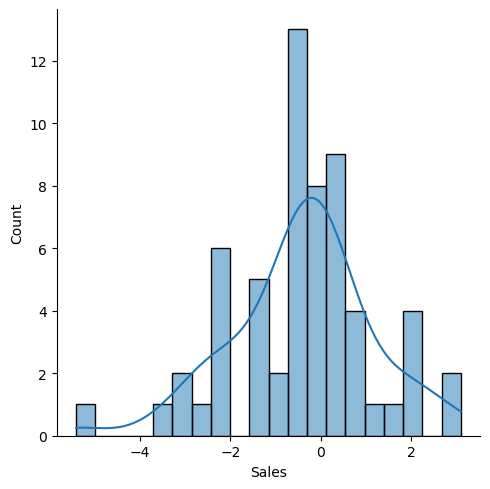

In [74]:
#testing for normality
sns.displot(residuals, bins=20, kde=True)

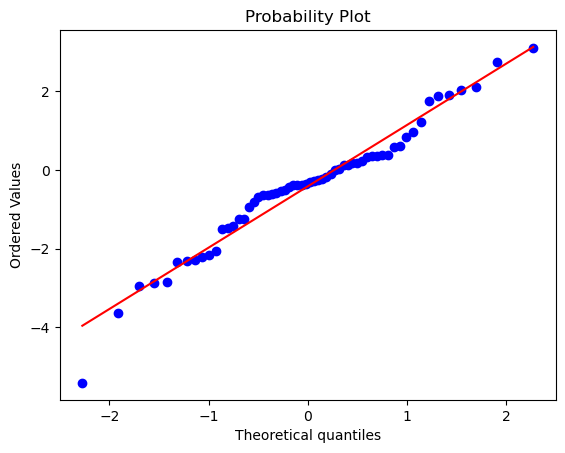

In [75]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()